In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
credit_df = pd.read_csv("credit_train_clean.csv").drop(["Name", "SSN"], axis=1)
 
credit_df.head()

,ID,Customer_ID,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,5634,3392,1,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,...,Good,809.98,26.822620,265.0,No,49.574949,21.46538,High_spent_Small_value_payments,312.494089,Good
1,5635,3392,2,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,...,Good,809.98,31.944960,266.0,No,49.574949,21.46538,Low_spent_Large_value_payments,284.629162,Good
2,5636,3392,3,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,...,Good,809.98,28.609352,267.0,No,49.574949,21.46538,Low_spent_Medium_value_payments,331.209863,Good
3,5637,3392,4,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,...,Good,809.98,31.377862,268.0,No,49.574949,21.46538,Low_spent_Small_value_payments,223.451310,Good
4,5638,3392,5,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,...,Good,809.98,24.797347,269.0,No,49.574949,21.46538,High_spent_Medium_value_payments,341.489231,Good


In [4]:
credit_df["Credit_Score"].value_counts()

Credit_Score
Standard    53174
Poor        28998
Good        17828
Name: count, dtype: int64

In [5]:
from sklearn.model_selection import train_test_split
 
features = [
    "Age",
    "Month",
    "Annual_Income",
    "Num_Bank_Accounts",
    "Changed_Credit_Limit",
    "Num_Credit_Card",
    "Credit_History_Age",
    "Payment_of_Min_Amount",
    "Monthly_Balance",
    "Payment_Behaviour",
    "Num_Credit_Inquiries",
    "Outstanding_Debt",
    "Credit_Mix",
    "Total_EMI_per_month"
]
 
X = pd.get_dummies(credit_df[features], dtype="int", drop_first=True)
y = credit_df["Credit_Score"]
 
 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2023)

In [6]:
X_test.head()

,Age,Month,Annual_Income,Num_Bank_Accounts,Changed_Credit_Limit,Num_Credit_Card,Credit_History_Age,Monthly_Balance,Num_Credit_Inquiries,Outstanding_Debt,Total_EMI_per_month,Payment_of_Min_Amount_No,Payment_of_Min_Amount_Yes,Payment_Behaviour_High_spent_Medium_value_payments,Payment_Behaviour_High_spent_Small_value_payments,Payment_Behaviour_Low_spent_Large_value_payments,Payment_Behaviour_Low_spent_Medium_value_payments,Payment_Behaviour_Low_spent_Small_value_payments,Credit_Mix_Good,Credit_Mix_Standard
65740,42.0,5,39849.72,9.0,9.12,8.0,73.0,384.540284,14.0,2533.64,96.604035,0,1,0,0,0,1,0,0,1
11139,50.0,4,16558.12,3.0,3.57,7.0,232.0,247.055794,1.0,15.43,35.387555,1,0,0,0,0,0,1,1,0
99196,35.0,5,96047.22,3.0,4.75,3.0,212.0,742.619597,4.0,1366.21,49.656727,1,0,1,0,0,0,0,1,0
33120,26.0,1,32904.13,2.0,7.43,7.0,189.0,326.879129,2.0,781.45,46.033182,1,0,0,1,0,0,0,1,0
41199,27.0,8,32428.98,6.0,21.88,5.0,132.0,329.887223,11.0,4903.14,109.273296,0,0,0,0,0,1,0,0,0


In [8]:
from sklearn.linear_model import LogisticRegression
 
 
lr = LogisticRegression(max_iter=5000)
lr.fit(X_train, y_train)
 
print(lr.score(X_train, y_train))
print(lr.score(X_test, y_test))
 
lr.classes_
 

0.6188875
0.6129


c:\BIT_Data_analyst\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


array(['Good', 'Poor', 'Standard'], dtype=object)

In [9]:
from sklearn.metrics import confusion_matrix
 
confusion_matrix(y_train, lr.predict(X_train))

array([[ 4414,   259,  9557],
       [  991, 11343, 10849],
       [ 3000,  5833, 33754]])

In [10]:
from sklearn.metrics import confusion_matrix
 
confusion_matrix(y_test, lr.predict(X_test))

array([[1125,   62, 2411],
       [ 256, 2762, 2797],
       [ 785, 1431, 8371]])

In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
 
y_pred = lr.predict(X_test)
 
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average=None))
print("Recall:", recall_score(y_test, y_pred, average=None))
print("F1-score:", f1_score(y_test, y_pred, average=None))
 
print(classification_report(y_test, y_pred))

Accuracy: 0.6129
Precision: [0.51939058 0.64911868 0.6164666 ]
Recall: [0.31267371 0.4749785  0.79068669]
F1-score: [0.39035392 0.54856008 0.69279153]
              precision    recall  f1-score   support

        Good       0.52      0.31      0.39      3598
        Poor       0.65      0.47      0.55      5815
    Standard       0.62      0.79      0.69     10587

    accuracy                           0.61     20000
   macro avg       0.59      0.53      0.54     20000
weighted avg       0.61      0.61      0.60     20000



In [12]:
from sklearn.ensemble import RandomForestClassifier
 
 
rf = RandomForestClassifier(n_estimators = 10, random_state = 42)
rf.fit(X_train, y_train)
 
rf.score(X_test, y_test)

0.7881

In [13]:
loan_df["income"] = loan_df["income"].fillna(loan_df["income"].mean()) #
loan_df["loan_amount"] = loan_df["loan_amount"].fillna(loan_df["loan_amount"].mean()) #
loan_df["rate_of_interest"] = loan_df["rate_of_interest"].fillna(loan_df["rate_of_interest"].mean()) #
loan_df["approv_in_adv"] = loan_df["approv_in_adv"].fillna(loan_df["approv_in_adv"].mode()) #
 
 
 
loan_df = loan_df.assign(
    total_units = loan_df["total_units"].map({
        "1U": "1U",
        "2U": "2U+",
        "3U": "2U+",
        "4U": "2U+"}),
    loan_amt_v_income = loan_df["loan_amount"]/loan_df["income"]
)
 
loan_df.head()
 

NameError: name 'loan_df' is not defined

In [16]:
loan_df = pd.read_csv(r"C:\BIT_Data_analyst\06_machine learning\01_lesson\Loan_Default.csv")
 
loan_df.head()

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


In [17]:
loan_df["income"] = loan_df["income"].fillna(loan_df["income"].mean()) #
loan_df["loan_amount"] = loan_df["loan_amount"].fillna(loan_df["loan_amount"].mean()) #
loan_df["rate_of_interest"] = loan_df["rate_of_interest"].fillna(loan_df["rate_of_interest"].mean()) #
loan_df["approv_in_adv"] = loan_df["approv_in_adv"].fillna(loan_df["approv_in_adv"].mode()) #
 
 
 
loan_df = loan_df.assign(
    total_units = loan_df["total_units"].map({
        "1U": "1U",
        "2U": "2U+",
        "3U": "2U+",
        "4U": "2U+"}),
    loan_amt_v_income = loan_df["loan_amount"]/loan_df["income"]
)
 
loan_df.head()
 

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1,loan_amt_v_income
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0,66.954023
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN,41.465863
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0,42.879747
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0,38.425926
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0,66.714559


In [18]:
prep_loan_df = loan_df.drop([
    "year",
     "ID",
     "open_credit",
    "construction_type",
    "Security_Type",
    "Secured_by"],
    axis=1
)
 
prep_loan_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 29 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   loan_limit                 145326 non-null  str    
 1   Gender                     148670 non-null  str    
 2   approv_in_adv              147762 non-null  str    
 3   loan_type                  148670 non-null  str    
 4   loan_purpose               148536 non-null  str    
 5   Credit_Worthiness          148670 non-null  str    
 6   business_or_commercial     148670 non-null  str    
 7   loan_amount                148670 non-null  int64  
 8   rate_of_interest           148670 non-null  float64
 9   Interest_rate_spread       112031 non-null  float64
 10  Upfront_charges            109028 non-null  float64
 11  term                       148629 non-null  float64
 12  Neg_ammortization          148549 non-null  str    
 13  interest_only              148670 non-nu

In [26]:
from sklearn.model_selection import train_test_split
 
features = [
    "loan_amount",
    "income",
    "Gender",
    #"rate_of_interest", #
    "age",
    "lump_sum_payment",
    "credit_type",
    "total_units",
    "Credit_Worthiness",
    "Credit_Score",
    "approv_in_adv",
 
]
 
X = pd.get_dummies(prep_loan_df[features], drop_first=True)
y = prep_loan_df["Status"]
 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=12345)

In [27]:
from sklearn.tree import DecisionTreeClassifier
 
dt = DecisionTreeClassifier()
dt = dt.fit(X_train, y_train)
 
print(f"Train Score: {dt.score(X_train, y_train)}")
print(f"Test Score: {dt.score(X_test, y_test)}")

Train Score: 0.9998991054012242
Test Score: 0.7703302616533262


In [28]:
from sklearn.metrics import confusion_matrix
 
confusion_matrix(y_test, dt.predict(X_test))

array([[18667,  3678],
       [ 3151,  4238]])

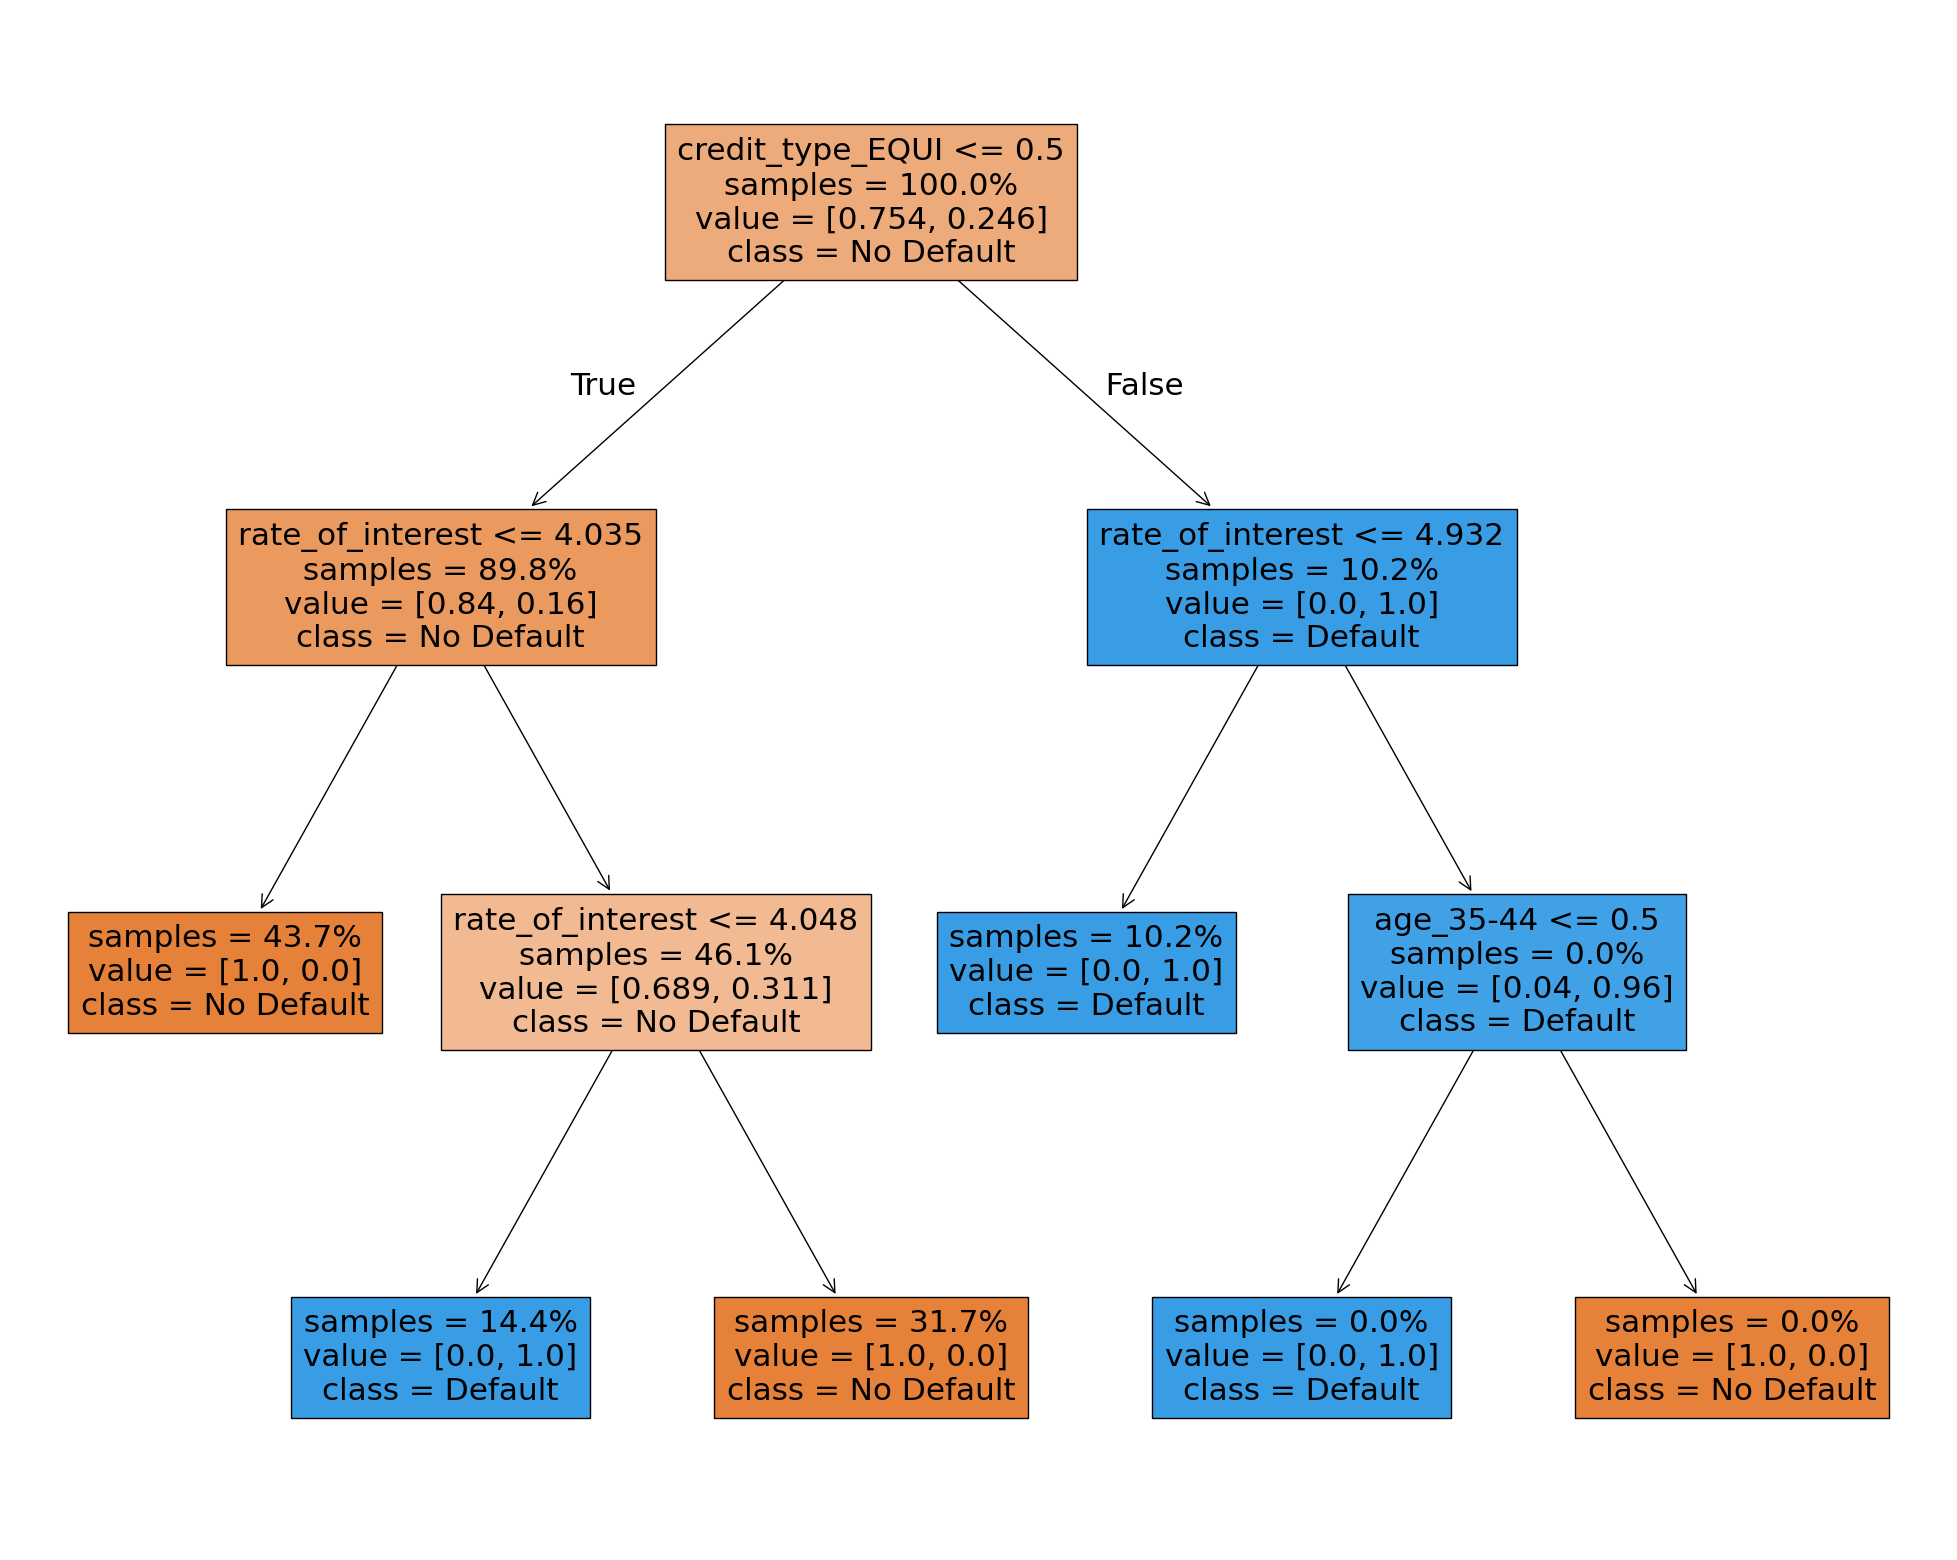

In [22]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
 
fig = plt.figure(figsize=(25,20))
 
plot_tree(
    dt,
    feature_names=list(X_train.columns),
    class_names=["No Default", "Default"],
    impurity=False,
    proportion=True,
    filled=True
);

In [23]:
dt.feature_names_in_
 

array(['loan_amount', 'income', 'rate_of_interest', 'Credit_Score',
       'Gender_Joint', 'Gender_Male', 'Gender_Sex Not Available',
       'age_35-44', 'age_45-54', 'age_55-64', 'age_65-74', 'age_<25',
       'age_>74', 'lump_sum_payment_not_lpsm', 'credit_type_CRIF',
       'credit_type_EQUI', 'credit_type_EXP', 'total_units_2U+',
       'Credit_Worthiness_l2', 'approv_in_adv_pre'], dtype=object)

In [24]:
from sklearn.tree import DecisionTreeClassifier
 
dt = DecisionTreeClassifier()
dt = dt.fit(X_train, y_train)
 
print(f"Train Score: {dt.score(X_train, y_train)}")
print(f"Test Score: {dt.score(X_test, y_test)}")

Train Score: 1.0
Test Score: 1.0


In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
 
fig = plt.figure(figsize=(25,20))
 
plot_tree(
    dt,
    feature_names=list(X_train.columns),
    class_names=["No Default", "Default"],
    impurity=False,
    proportion=True,
    filled=True
);

Error in callback <function _draw_all_if_interactive at 0x000001B6C34EF5E0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
df = pd.read_csv('kyphosis.csv')

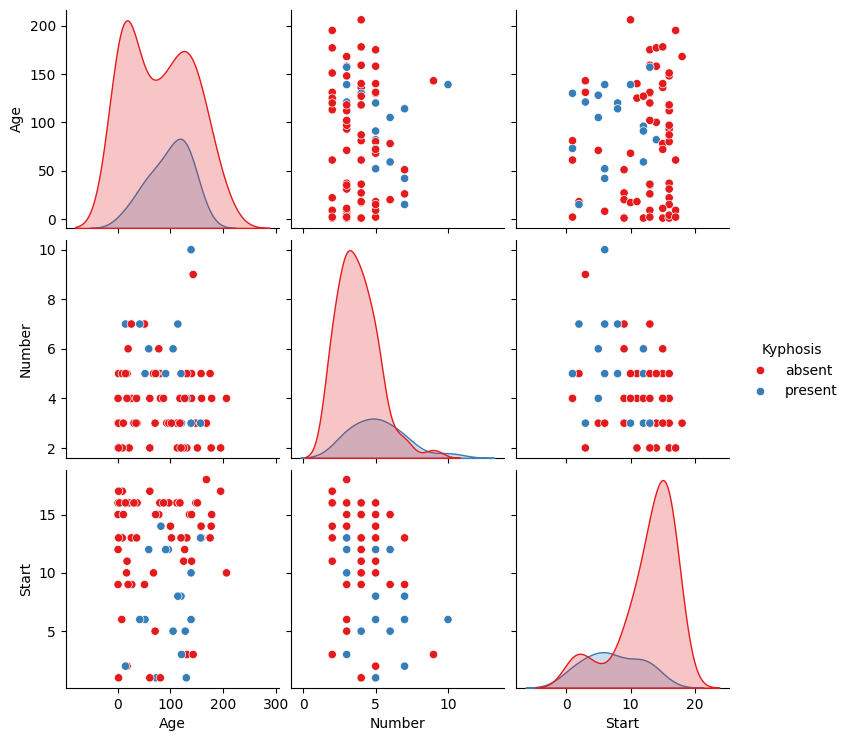

In [4]:
sns.pairplot(df,hue='Kyphosis',palette='Set1')

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
X = df.drop('Kyphosis',axis=1)
y = df['Kyphosis']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30)

In [8]:
from sklearn.tree import DecisionTreeClassifier

In [9]:
dtree = DecisionTreeClassifier()

In [10]:
dtree.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [11]:
predictions = dtree.predict(X_test)

In [12]:
print(predictions)

['absent' 'absent' 'absent' 'absent' 'present' 'present' 'absent' 'absent'
 'absent' 'present' 'absent' 'absent' 'absent' 'absent' 'absent' 'present'
 'absent' 'absent' 'absent' 'absent' 'absent' 'absent' 'absent' 'present'
 'absent']


In [13]:
from sklearn.metrics import classification_report,confusion_matrix

In [14]:
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

      absent       0.80      0.94      0.86        17
     present       0.80      0.50      0.62         8

    accuracy                           0.80        25
   macro avg       0.80      0.72      0.74        25
weighted avg       0.80      0.80      0.79        25



In [15]:
print(confusion_matrix(y_test,predictions))

[[16  1]
 [ 4  4]]


In [17]:
from IPython.display import Image
from io import StringIO
from sklearn.tree import export_graphviz
import pydot
 
features = list(df.columns[1:])
features

['Age', 'Number', 'Start']

In [18]:
dot_data = StringIO()  
export_graphviz(dtree, out_file=dot_data,feature_names=features,filled=True,rounded=True)
 
graph = pydot.graph_from_dot_data(dot_data.getvalue())  
Image(graph[0].create_png())  

FileNotFoundError: [WinError 2] "dot" not found in path.

In [19]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(n_estimators=100)
rfc.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric